In [1]:
import math
import joblib
import keras

import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from keras import activations, layers, initializers
from keras.models import Model
from keras.optimizers.legacy import Adam

from src.wrapper import trainer

from matplotlib import pyplot as plt
import matplotlib.patches as patches
from src import grid_augmentation as ga

from timeit import default_timer

import scienceplots
plt.style.use('science')

import warnings
warnings.filterwarnings("ignore")


In [2]:
params = {'xtick.labelsize':12,
          'ytick.labelsize':12,
          'axes.labelsize': 16,
          'axes.titlesize': 18}
plt.rcParams.update(params)

In [3]:
def func1(x, noise_scale=0.05):
    eps = np.random.normal(0, noise_scale, x.shape[0])
    return np.sin(2 * np.pi * x**2) * np.exp(-x) + 1 + eps

def interval_input(x, min_width, max_width):
    radii = np.random.uniform(min_width,max_width,size=x.shape[0])/2
    x_lo = x - radii
    x_hi = x + radii

    return x_lo, x_hi

def interval_propagation(x_int, noise=0):
    y_int = []
    for x_i in tqdm(x_int):
        samp = np.linspace(x_i[0], x_i[1], 100)
        y_samp = func1(samp, noise_scale=noise)
        y_lo = np.min(y_samp)
        y_hi = np.max(y_samp)
        y_i = np.array([y_lo,y_hi])
        y_int.append(y_i)
    y_int = np.array(y_int)
    return y_int
        

In [4]:
### Create pointwise data ###
x_points = np.linspace(0,1,500)
y_noiseless = func1(x_points, noise_scale=0.0)
y_points = func1(x_points, noise_scale=0.025)

# Choose 50 random as training data
np.random.seed(17)
x_train = np.random.choice(x_points, size=50, replace=False)
y_train = func1(x_train, noise_scale=0.025)

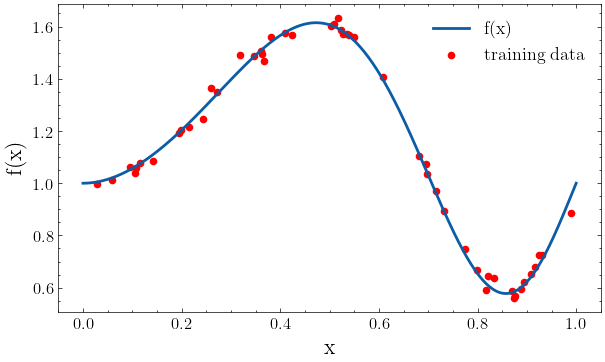

In [5]:
# Plot
fig, ax = plt.subplots(figsize=(7, 4))

line = ax.plot(x_points,y_noiseless,linewidth=2, label="f(x)")
scatter = ax.scatter(x_train,y_train, s=20, c="red", label="training data")

ax.set_xlabel("x", fontsize=16)
ax.set_ylabel("f(x)", fontsize=16)
# Add final legend
ax.legend(fontsize=13)

plt.savefig("img/basic_1dreg.pdf", dpi=300, format="pdf")
plt.show()

In [6]:
### Construct interval TEST data ###
x_lo,x_hi = interval_input(x_points, min_width=0.015, max_width=0.075)
x_int = np.stack([x_lo.T, x_hi.T], axis=1)
y_int = interval_propagation(x_int, noise=0.025)
y_int_noiseless = interval_propagation(x_int, noise=0)

100%|██████████| 500/500 [00:00<00:00, 42852.37it/s]


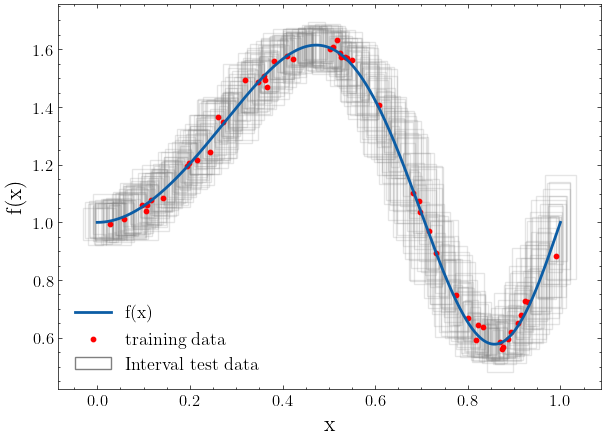

In [7]:
# Plot
fig, ax = plt.subplots(figsize=(7, 5))

for i in range(len(x_int)):
    x_lo, x_hi = x_int[i]
    y_lo, y_hi = y_int[i]
    width = x_hi - x_lo
    height = y_hi - y_lo
    rect = patches.Rectangle((x_lo, y_lo), width, height,
                             linewidth=1, edgecolor='grey', facecolor='none', alpha=0.2)
    ax.add_patch(rect)

rect_legend = patches.Patch(edgecolor='grey', facecolor='none', label='interval test')
line = ax.plot(x_points,y_noiseless,linewidth=2, label="f(x)")
scatter = ax.scatter(x_train,y_train, s=10, c="red", label="training data")

# Get existing handles and labels
handles, labels = ax.get_legend_handles_labels()

# Append custom rectangle legend
handles.append(rect_legend)
labels.append('Interval test data')

ax.set_xlabel("x", fontsize=16)
ax.set_ylabel("f(x)", fontsize=16)
# Add final legend
ax.legend(handles=handles, labels=labels, fontsize=13)

plt.savefig("img/aug_1dreg.pdf", dpi=300, format="pdf")
plt.show()

## Grid Augmentation

In [8]:
np.linspace(0.05,0.35,9)

array([0.05  , 0.0875, 0.125 , 0.1625, 0.2   , 0.2375, 0.275 , 0.3125,
       0.35  ])

In [9]:
grid_res = [[a] for a in np.linspace(0.05,0.35,9)]
x_train_int, y_train_int = ga.construct_interval_grid(x_train, y_train, 
                                                     grid_res=grid_res, n_shift=3, nmax_per_res=25)

100%|██████████| 9/9 [00:00<00:00, 764.33it/s]

Grid resolution [0.05] has 25 data
Grid resolution [0.0875] has 25 data
Grid resolution [0.125] has 24 data
Grid resolution [0.16249999999999998] has 19 data
Grid resolution [0.2] has 16 data
Grid resolution [0.2375] has 14 data
Grid resolution [0.27499999999999997] has 13 data
Grid resolution [0.3125] has 11 data
Grid resolution [0.35] has 10 data


In [10]:
x_train_int.shape

(157, 1, 2)

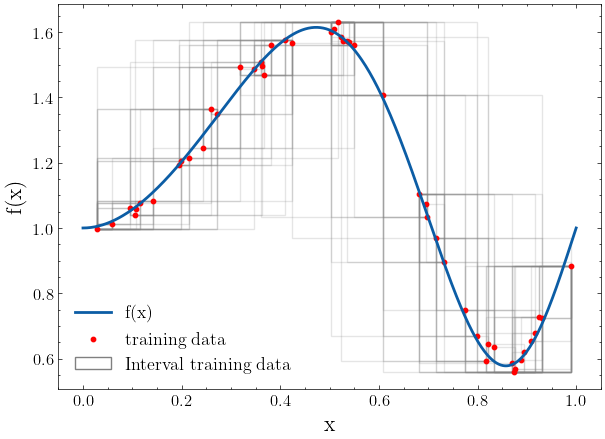

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

for i in range(len(x_train_int)):
    x_lo, x_hi = x_train_int[i,0]
    y_lo, y_hi = y_train_int[i,0]
    width = x_hi - x_lo
    height = y_hi - y_lo
    rect = patches.Rectangle((x_lo, y_lo), width, height,
                             linewidth=1, edgecolor='grey', facecolor='none', alpha=0.2)
    ax.add_patch(rect)

rect_legend = patches.Patch(edgecolor='grey', facecolor='none', label='interval test')
line = ax.plot(x_points,y_noiseless,linewidth=2, label="f(x)")
scatter = ax.scatter(x_train,y_train, s=10, c="red", label="training data")

# Get existing handles and labels
handles, labels = ax.get_legend_handles_labels()

# Append custom rectangle legend
handles.append(rect_legend)
labels.append('Interval training data')

ax.set_xlabel("x", fontsize=16)
ax.set_ylabel("f(x)", fontsize=16)
# Add final legend
ax.legend(handles=handles, labels=labels, fontsize=13)

plt.savefig("img/aug_1dreg_train.pdf", dpi=300, format="pdf")
plt.show()

## Naive IMLP

In [12]:
def naiveimlp(input_shape, hidden_layers=[32,64,32], output_size=2):
    """interval multilayer perceptron constructor

    Args:
        input_shape (_type_): _description_
        n_hidden_layers (int, optional): Number of hidden layers. Defaults to 1.
    """

    assert type(hidden_layers) == list , "Hidden layers should be a list."
    assert type(output_size) == int and output_size > 0, "Output size should be an integer and greater than 0"

    # Input layers
    inputs = keras.Input(input_shape)

    # MLP hidden layers
    for idx,n_layers in enumerate(hidden_layers):
        if idx == 0:
            x = layers.Dense(n_layers,activation="silu")(inputs)
        else:
            x = layers.Dense(n_layers,activation="silu")(x)
    
    # MLP output layers
    outputs = layers.Dense(output_size, activation=None)(x)

    model = keras.Model(inputs, outputs, name="NaiveIMLP")

    return model

In [13]:
def linex_loss(d,a):
    """Linear-exponential loss"""
    b = 2
    term1 = (tf.exp(-a*d)+(a*d)-1)
    return b*term1

def neg_distance_pen(dist):
     """Negative distance penalty"""
     return tf.where(dist < 0, (5*dist)**2, 0)

def custom_loss(target, y_pred, linex_a=5):
    err_lo = (target[...,0] - y_pred[...,0]) #preds better be lower than target
    err_hi = (y_pred[...,1] - target[...,1]) #target better be lower than preds
    term1 = linex_loss(err_lo, a=linex_a)
    term2 = linex_loss(err_hi, a=linex_a)
    dist = y_pred[...,1]-y_pred[...,0]
    loss = tf.reduce_mean(term1) + tf.reduce_mean(term2) + tf.reduce_mean(neg_distance_pen(dist))

    return loss

In [14]:
inn = naiveimlp(input_shape=2, hidden_layers=[16,16,16], output_size=2)

2026-02-19 11:46:13.368309: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-02-19 11:46:13.368336: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-19 11:46:13.368341: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-02-19 11:46:13.368526: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-19 11:46:13.368811: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [15]:
x_train_int = x_train_int.reshape(x_train_int.shape[0],2)
y_train_int = y_train_int.reshape(y_train_int.shape[0],2)

In [16]:
x_train_int.shape

(157, 2)

In [17]:
class ConformalCalib():
    def __init__(self, y_l_calib, y_u_calib, alpha=0.1, method="interval"):
        assert method in ["interval","local","spatial"]
        self.y_l_calib = y_l_calib
        self.y_u_calib = y_u_calib
        self.alpha = alpha
        self.method = method
        self.q_conformal = 0
        self.residuals = None
    
    def calibrate(self, pred_l, pred_u):
        assert np.ndim(pred_l) == np.ndim(self.y_l_calib)
        if self.method == "interval":
            residuals = np.maximum(pred_l - self.y_l_calib, self.y_u_calib - pred_u)
        elif self.method == "local":
            interval_length = pred_u - pred_l
            residuals = np.maximum(pred_l - self.y_l_calib, self.y_u_calib - pred_u)/interval_length
        else:
            raise ValueError("Method haven't been implemented")
        
        n_cal = len(residuals)
        if self.alpha <= 1 and self.alpha > 0:
            quantile_level = np.ceil((n_cal + 1) * (1 - self.alpha)) / n_cal
            if quantile_level > 1:
                print(f"Warning: Quantile level = {quantile_level} calculated. Check alpha and n_cal. Setting quantile level to 1.")
                quantile_level = 1
            elif  quantile_level <= 0:
                print(f"Warning: Quantile level = {quantile_level} calculated. Check alpha and n_cal. Setting quantile level to 0.")
                quantile_level = 0
            else:
                pass

        elif self.alpha > 1:
            raise ValueError("alpha greater than 1")
        else:
            quantile_level = 1
        
        self.q_conformal = np.quantile(
                            residuals,
                            quantile_level
                        )
        self.residuals = residuals
    
    def conformalize(self, pred_l, pred_u):
        if self.method == "interval":
            lb_conf = pred_l - self.q_conformal
            ub_conf = pred_u + self.q_conformal
        elif self.method == "local":
            pred_length = pred_u - pred_l
            pred_mid = (pred_l + pred_u)/2
            lb_conf = pred_mid - (self.q_conformal * pred_length)
            ub_conf = pred_mid + (self.q_conformal * pred_length)
        else:
            raise ValueError("Method haven't been implemented")
        
        return lb_conf, ub_conf


In [18]:
class DelayedBestWeights(tf.keras.callbacks.Callback):
    def __init__(self, monitor='loss', mode='min', start_epoch=100):
        super().__init__()
        self.monitor = monitor
        self.mode = mode
        self.start_epoch = start_epoch
        self.best_value = np.inf if mode == 'min' else -np.inf
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        current_value = logs.get(self.monitor)
        if epoch >= self.start_epoch:
            if (self.mode == 'min' and current_value < self.best_value) or \
               (self.mode == 'max' and current_value > self.best_value):
                self.best_value = current_value
                self.best_weights = self.model.get_weights()
                # print(f" Best weights updated at epoch {epoch+1} with {self.monitor}={current_value:.4f}")

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)
            print(f"Restored best model from epoch after {self.start_epoch} "
                  f"with {self.monitor}={self.best_value:.4f}")
        else:
            print(f"No improvement found after epoch {self.start_epoch}")

In [19]:
def run_experiment(x_int_train, y_int_train, x_test_int, y_test_int, loss_fun, 
                   cal_source="augmented", conformal_fun="interval", n_cal=50,
                   alpha=0.1, repetitions=10, n_train = 50, epochs=1000, verbose=0):
    """Run the experiment with the given model and data."""

    assert cal_source in ["augmented", "interval"]

    results = []
    # Choose n_train random as training data
    for seed in tqdm(range(repetitions)):
        model = naiveimlp(input_shape=2, hidden_layers=[16,16,16], output_size=2)
        # Compile model
        model.compile(optimizer=Adam(learning_rate=1e-2), loss=loss_fun)

        data = dict()
        np.random.seed(seed)
        training_indices = np.arange(x_int_train.shape[0])
        idx_train = np.random.choice(training_indices, size=n_train, replace=False)
        x_train_int = x_int_train[idx_train]
        y_train_int = y_int_train[idx_train]   

        x_int_test = x_test_int.copy()
        y_int_test = y_test_int.copy()
        if cal_source == "augmented":
            assert n_cal + n_train <= x_int_train.shape[0], "Not enough data for training and calibration"
            calibration_indices = np.setdiff1d(training_indices, idx_train)
            idx_cal = np.random.choice(calibration_indices, size=n_cal, replace=False)
            x_cal_int = x_int_train[idx_cal]
            y_cal_int = y_int_train[idx_cal]
        else:
            test_indices = np.arange(x_int_test.shape[0])
            idx_cal = np.random.choice(test_indices, size=n_cal, replace=False)
            x_cal_int = x_int_test[idx_cal]
            y_cal_int = y_int_test[idx_cal]
            x_int_test = np.delete(x_int_test, idx_cal, axis=0)
            y_int_test = np.delete(y_int_test, idx_cal, axis=0)

        best_weights_cb = DelayedBestWeights(monitor='loss', mode='min', start_epoch=1000)
        # Train model
        t0 = default_timer()
        history = model.fit(x=x_train_int, y=y_train_int, epochs=epochs, verbose=verbose, callbacks=[best_weights_cb])
        data["training_time"] = default_timer() - t0

        # Conformal calibration
        pred_cal = model.predict(x_cal_int)
        conformalizer = ConformalCalib(y_cal_int[...,0], y_cal_int[...,1], alpha=alpha, method=conformal_fun)
        conformalizer.calibrate(pred_cal[...,0], pred_cal[...,1])

        # Evaluate model
        pred = model.predict(x_int_test)
        # Add conformalization
        if n_cal > 0:
            pred_l_conf, pred_u_conf = conformalizer.conformalize(pred[...,0], pred[...,1])
            pred_conf = np.stack([pred_l_conf, pred_u_conf], axis=-1)
            data["pred_conformal"] = pred_conf
        else:
            data["pred_conformal"] = None
            
        data["x_train"] = x_train_int
        data["y_train"] = y_train_int
        data["x_test"] = x_int_test
        data["y_test"] = y_int_test
        data["pred"] = pred
        data["history"] = history.history

        results.append(data)
        
    return results

In [20]:
for ncal in [50]:
    results = run_experiment(x_train_int, y_train_int, x_int, y_int, loss_fun=custom_loss,
                            repetitions=5, n_train=50, epochs=3000, cal_source="interval", n_cal=ncal, alpha=0.05, 
                            conformal_fun="interval", verbose=0)
    # joblib.dump(results, f"output/simple1dreg_conf/simple1dreg_aug_naive_ntrain50_calibaug_conf{ncal}_a050.pkl")

  0%|          | 0/5 [00:00<?, ?it/s]2026-02-19 11:46:14.128207: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Restored best model from epoch after 1000 with loss=0.1371
15/15 [==============================] - 0s 4ms/step


 20%|██        | 1/5 [01:05<04:23, 65.99s/it]

Restored best model from epoch after 1000 with loss=0.1747
15/15 [==============================] - 0s 5ms/step


 40%|████      | 2/5 [02:18<03:30, 70.05s/it]

...

 60%|██████    | 3/5 [03:23<02:15, 67.72s/it]

Restored best model from epoch after 1000 with loss=0.0623
15/15 [==============================] - 0s 4ms/step


 80%|████████  | 4/5 [04:29<01:06, 66.91s/it]

Restored best model from epoch after 1000 with loss=0.0943
15/15 [==============================] - 0s 4ms/step


100%|██████████| 5/5 [05:36<00:00, 67.39s/it]


Inverted predicted interval count: 1/500


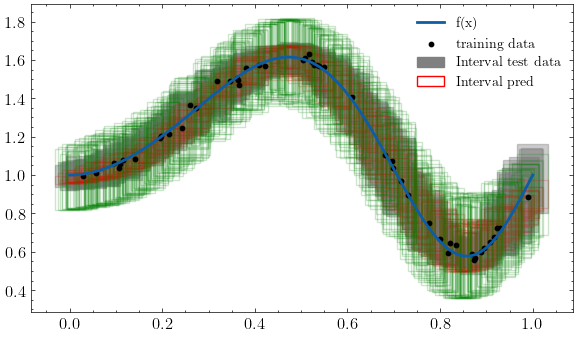

In [ ]:
id = 0 # Experiment ID
fig, ax = plt.subplots(figsize=(7, 4))

data = results[id]
x_train_int = data["x_train"]
y_train_int = data["y_train"]
x_test_int = data["x_test"]
y_test_int = data["y_test"]
pred = data["pred"]
pred_conf = data["pred_conformal"]
history = data["history"]

for i in range(len(x_test_int)):
    x_lo, x_hi = x_test_int[i]
    y_lo, y_hi = y_test_int[i]
    width = x_hi - x_lo
    height = y_hi - y_lo
    rect = patches.Rectangle((x_lo, y_lo), width, height,
                             linewidth=1, edgecolor='grey', facecolor='grey', alpha=0.4)
    ax.add_patch(rect)

inverted_count = 0
for i in range(len(x_test_int)):
    x_lo, x_hi = x_test_int[i]
    width = x_hi - x_lo
    height2 = pred[i,1] - pred[i,0]
    if height2 < 0:
        inverted_count += 1
    rect2 = patches.Rectangle((x_lo, pred[i,0]), width, height2,
                             linewidth=1, edgecolor='red', facecolor='none', alpha=0.2)
    ax.add_patch(rect2)
for i in range(len(x_test_int)):
    x_lo, x_hi = x_test_int[i]
    width = x_hi - x_lo
    height3 = pred_conf[i,1] - pred_conf[i,0]
    rect3 = patches.Rectangle((x_lo, pred_conf[i,0]), width, height3,
                             linewidth=1, edgecolor='green', facecolor='none', alpha=0.2)
    ax.add_patch(rect3)

print(f"Inverted predicted interval count: {inverted_count}/{len(x_int)}")
rect_legend = patches.Patch(edgecolor='grey', facecolor='grey', label='interval test')
rect_legend2 = patches.Patch(edgecolor='red', facecolor='none', label='interval pred')
line = ax.plot(x_points,y_noiseless,linewidth=2, label="f(x)")
mid_x = (x_int[:,1] + x_int[:,0])/2
scatter = ax.scatter(x_train,y_train, s=10, c="black", label="training data")

# Get existing handles and labels
handles, labels = ax.get_legend_handles_labels()

# Append custom rectangle legend
handles.append(rect_legend)
handles.append(rect_legend2)
labels.append('Interval test data')
labels.append('Interval pred')

# Add final legend
ax.legend(handles=handles, labels=labels)

plt.show()

In [22]:
lo = []
hi = []
for res in results:
    pred = res["pred"]
    x_test_int = res["x_test"]
    y_test_int = res["y_test"]
    rmse_lo = np.sqrt(np.mean((pred[:,0] - y_test_int[:,0])**2))
    rmse_hi = np.sqrt(np.mean((pred[:,1] - y_test_int[:,1])**2))

    lo.append(rmse_lo)
    hi.append(rmse_hi)

# print RMSE values with 3 decimal places
print(f"RMSE lower: {np.round(np.mean(lo),3)} \u00B1 {np.round(np.std(lo),3)} \nRMSE upper: {np.round(np.mean(hi),3)} \u00B1 {np.round(np.std(hi),3 )}")

RMSE lower: 0.048 ± 0.015 
RMSE upper: 0.065 ± 0.017
